# Data Preprocessing — Dallas Office ERV (Layer 1 Hedonic Model)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import re
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR   = "./"
CREXI_FILE = DATA_DIR + "Crexi_Dallas.xlsx"
FRED_FILE  = DATA_DIR + "FRED_Macro_Panel_Dallas.xlsx"
GS_FILE    = DATA_DIR + "GreenStreet - Submarket Grades.xlsx"

## 2. Load Raw Data

In [2]:
lease_raw = pd.read_excel(CREXI_FILE, sheet_name="Lease comps")
sales_raw = pd.read_excel(CREXI_FILE, sheet_name="Sales comps")

fred_raw  = pd.read_excel(FRED_FILE, sheet_name="Quarterly Panel")

gs_xl = pd.ExcelFile(GS_FILE)
print("GreenStreet sheets:", gs_xl.sheet_names)

GreenStreet sheets: ['TOC', 'Apartment Market Grades', 'Apartment Submarket Grades', 'Industrial Market Grades', 'Industrial Submarket Grades', 'Office Market Grades', 'Office Submarket Grades', 'Self-Storage Market Grades', 'Self-Storage Submarket Grades', 'Senior Housing Market Grades', 'Senior Housing Submarket Grades', 'Single-Family Market Grades', 'Single-Family Submarket Grades', 'Strip Market Grades', 'Strip Submarket Grades', 'Market Grade Methodology']


In [3]:
print("Lease comps shape:", lease_raw.shape)
print("\nColumns:", lease_raw.columns.tolist())
lease_raw.head(3)

Lease comps shape: (932, 42)

Columns: ['Record type', 'Property type', 'Property subtype', 'Interest rate', 'Date sold', 'Sold price', 'Sold price/sqft', 'Property name', 'Total monthly rate', 'Loan amount', 'Loan type', 'Lease rate', 'Financing maturity date', 'Title company', 'Building sqft', 'Number of units', 'Unit beds', 'Year built', 'Unit baths', 'Lot size acres', 'Sold price/acre', 'Lot size sqft', 'Asking cap rate', 'Sold cap rate', 'NOI', 'Occupancy', 'Lease type', 'Lease commencement', 'Lease term', 'Lease term remaining', 'Lease expiration date', 'Rent bumps', 'Lease options', 'Tenancy', 'Address', 'City', 'Zip code', 'State', 'County', 'Days on market', 'Building count', 'Transaction Type']


,Record type,Property type,Property subtype,Interest rate,Date sold,Sold price,Sold price/sqft,Property name,Total monthly rate,Loan amount,Loan type,Lease rate,Financing maturity date,Title company,Building sqft,Number of units,Unit beds,Year built,Unit baths,Lot size acres,Sold price/acre,Lot size sqft,Asking cap rate,Sold cap rate,NOI,Occupancy,Lease type,Lease commencement,Lease term,Lease term remaining,Lease expiration date,Rent bumps,Lease options,Tenancy,Address,City,Zip code,State,County,Days on market,Building count,Transaction Type
0,Sale Comp Lease Data,Office,Traditional Office,6.3%,"Mar 20, 2026","$84,075",$95,Pecan Creek Office Park (8330 Meadow Rd),NaN,"$25,000",Building or Construction Loan,NaN,NaN,NONE LISTED ON DOCUMENT,"106,406",120.00,NaN,1979.00,NaN,6.84,"$12,298","297,811",NaN,NaN,NaN,0%,"Ground, NNN",NaN,NaN,25.8 years,"Jan 1, 2052",No,NaN,Single,8330 MEADOW RD,DALLAS,75231,TX,DALLAS COUNTY,93.00,1.00,NaN
1,Sale Comp Lease Data,"Industrial, Office","Distribution, Traditional Office, Warehouse",6.7%,"Mar 17, 2026","$1,500,000",$68,"351 Interstate Highway 30, Greenville, TX 75402",NaN,"$2,061,000",New Conventional,NaN,"Oct 28, 2047",NaN,"22,000",1.00,NaN,1984.00,NaN,4.19,"$357,696","182,674",NaN,NaN,NaN,NaN,NaN,"Oct 1, 2024",NaN,NaN,NaN,No,NaN,Vacant,351 I-30 FRONTAGE RD,GREENVILLE,75402,TX,HUNT COUNTY,311.00,1.00,Arms-length Residential transactions (Purchase...
2,Sale Comp Lease Data,"Office, Retail",Medical Office,NaN,"Mar 11, 2026","$21,000,000","$1,721","Total Point ER | 20 Yr Abs NNN | Ennis, TX",NaN,NaN,NaN,NaN,NaN,NaN,"12,200",1.00,NaN,1999.00,NaN,NaN,"$28,920,791",NaN,8%,3.09%,"$648,000",NaN,Absolute NNN,NaN,20 years,NaN,NaN,Yes,2x 5 Year,Single,1611 W AVE,ENNIS,75119,TX,NaN,35.00,NaN,NaN


## 3. Crexi Lease Comps — Filter & Clean

**Target variable:** `Lease rate` ($/sqft/year).  
We keep only Office properties and remove records without a valid lease rate.

In [4]:
# ── 3.1  Filter to Office ─────────────────────────────────────────────────
print("Property types in lease comps:")
print(lease_raw["Property type"].value_counts())

Property types in lease comps:
Property type
Office                                                    727
Office, Retail                                             79
Industrial, Office                                         24
Mixed Use, Office, Retail                                  18
Office, Retail, Special Purpose                            16
Industrial, Office, Retail                                  9
Industrial, Mixed Use, Office                               7
Mixed Use, Office                                           7
Land, Office                                                6
Land, Mixed Use, Office, Retail                             5
Mixed Use, Office, Retail, Special Purpose                  4
Industrial, Mixed Use, Office, Retail                       3
Office, Self Storage                                        3
Land, Office, Retail                                        3
Industrial, Mixed Use, Office, Retail, Special Purpose      3
Mixed Use, Office, Specia

In [5]:
office = lease_raw[lease_raw["Property type"] == "Office"].copy()
print(f"Office leases: {len(office)}  (from {len(lease_raw)} total)")

Office leases: 727  (from 932 total)


In [6]:
# ── 3.2  Missing-value audit ──────────────────────────────────────────────
missing = (office.isnull().sum() / len(office) * 100).sort_values(ascending=False)
print("Missing % per column:")
print(missing[missing > 0].round(1).to_string())

Missing % per column:
Unit baths                99.20
Unit beds                 99.20
Sold cap rate             95.00
Lease options             94.60
Lease term remaining      93.80
Lease commencement        92.70
Lease expiration date     91.60
Lease term                89.40
Asking cap rate           79.60
NOI                       78.80
Days on market            69.10
Occupancy                 68.50
Financing maturity date   52.10
Total monthly rate        47.50
Lease rate                43.90
Lease type                38.10
Transaction Type          22.10
Property subtype          20.50
Loan type                 15.50
Title company             14.90
Number of units           14.70
Interest rate             14.30
Loan amount               13.90
Tenancy                   12.80
Building count             1.40
Lot size sqft              1.40
Lot size acres             1.40
Year built                 0.60
County                     0.30
Sold price/acre            0.10


In [7]:
# ── 3.3  Drop rows without target ────────────────────────────────────────
TARGET = "Lease rate"
office = office.dropna(subset=[TARGET])
print(f"After dropping missing target: {len(office)} rows")

After dropping missing target: 408 rows


In [8]:
office[TARGET].head(10)

6              $13.00
9     $16.50 - $17.50
11             $14.00
25             $24.50
28    $16.50 - $28.00
30                $24
34    $16.00 - $23.00
36     $0.04 - $25.00
37             $24.83
39             $18.90
Name: Lease rate, dtype: object

In [9]:
def parse_lease_rate(val):
   """
   Handles formats like:
   "$22.50"  |  "$18.00 - $25.00"  |  "$20/SF/YR"  |  "22.5 - 30"
   Returns the midpoint for ranges, the value itself otherwise.
   Returns NaN if unparseable.
   """
   if pd.isna(val):
      return np.nan
   s = str(val).replace("$", "").replace(",", "")
   s = re.sub(r"(?i)/sf.*|/yr.*|psf.*|per.*", "", s).strip()
   parts = re.split(r"\s*[-–]\s*", s)
   try:
      numbers = [float(p.strip()) for p in parts if p.strip()]
      return sum(numbers) / len(numbers)   # mean = midpoint for ranges
   except ValueError:
      return np.nan

# Show a sample of raw values before parsing
print("Sample raw Lease rate values:")
print(office[TARGET].dropna().head(10).tolist())
office[TARGET] = office[TARGET].apply(parse_lease_rate)
print("\nAfter parsing:")
print(office[TARGET].describe())
office[TARGET].head(10)

def parse_currency(val):
   """Strip $, commas; take midpoint for ranges. Returns NaN if unparseable."""
   if pd.isna(val):
      return np.nan
   s = str(val).replace("$", "").replace(",", "").strip()
   parts = re.split(r"\s*[-–]\s*", s)
   try:
      numbers = [float(p.strip()) for p in parts if p.strip()]
      return sum(numbers) / len(numbers)
   except ValueError:
      return np.nan

def parse_pct(val):
   """Strip % and convert to float (e.g. '6.3%' → 6.3). Returns NaN if unparseable."""
   if pd.isna(val):
      return np.nan
   try:
      return float(str(val).replace("%", "").strip())
   except ValueError:
      return np.nan
      
office["Interest rate"] = office["Interest rate"].apply(parse_pct)
office["Total monthly rate"] = office["Total monthly rate"].apply(parse_currency)
office["Loan amount"]        = office["Loan amount"].apply(parse_currency)
print(office[["Interest rate", "Total monthly rate", "Loan amount"]].dtypes)
print(office[["Interest rate", "Total monthly rate", "Loan amount"]].describe())

Sample raw Lease rate values:
['$13.00', '$16.50 - $17.50', '$14.00', '$24.50', '$16.50 - $28.00', '$24', '$16.00 - $23.00', '$0.04 - $25.00', '$24.83', '$18.90']

After parsing:
count     408.00
mean      978.10
std      6911.37
min         2.00
25%        16.48
50%        21.96
75%        28.00
max     99878.20
Name: Lease rate, dtype: float64
Interest rate         float64
Total monthly rate    float64
Loan amount           float64
dtype: object
       Interest rate  Total monthly rate  Loan amount
count         362.00              382.00       363.00
mean            4.77           437752.10  14809004.07
std             1.54          5921118.46  64968781.27
min             2.10               66.67     10000.00
25%             3.46             3081.14    614000.00
50%             4.22             6010.61   1550000.00
75%             6.39            15223.19   4825000.00
max             7.76        110822831.69 640000000.00


In [10]:
# Inspect the extremes to check for outliers or parsing errors
print(office[[TARGET]].sort_values(TARGET, ascending=False).head(20))
print("---")
print(office[[TARGET]].sort_values(TARGET).head(20))

     Lease rate
540    99878.20
701    55848.00
698    51000.00
345    45010.50
745    33600.00
324    16250.00
58     14400.00
628     9911.50
443     9018.50
917     8100.00
624     7806.00
396     6577.00
110     6400.00
850     6311.85
296     6000.00
268     5880.00
351     2280.57
149     1307.00
785      800.00
465      336.00
---
     Lease rate
751        2.00
391        4.97
514        5.43
235        6.43
567        6.95
519        6.98
560        7.00
121        7.72
642        8.45
116        9.00
761       10.00
844       10.00
622       10.00
545       10.00
834       10.25
767       10.25
872       10.40
269       10.95
422       11.00
880       11.00


In [11]:
# ── 3.4  Target distribution & outlier check ─────────────────────────────
print(office[TARGET].describe())
office[TARGET].head(10)
# Remove extreme outliers (below 1st pct or above 99th pct)
p01 = office[TARGET].quantile(0.01)
p99 = office[TARGET].quantile(0.99)
office = office[(office[TARGET] >= p01) & (office[TARGET] <= p99)]
print(f"\nAfter outlier trim [${p01:.1f}, ${p99:.1f}]: {len(office)} rows")

count     408.00
mean      978.10
std      6911.37
min         2.00
25%        16.48
50%        21.96
75%        28.00
max     99878.20
Name: Lease rate, dtype: float64

After outlier trim [$7.0, $32385.5]: 398 rows


In [12]:
office[TARGET].describe()

count     398.00
mean      285.68
std      1545.69
min         6.98
25%        16.50
50%        21.96
75%        27.94
max     16250.00
Name: Lease rate, dtype: float64

In [13]:
office.sort_values('Lease rate', ascending=False).head(10)

,Record type,Property type,Property subtype,Interest rate,Date sold,Sold price,Sold price/sqft,Property name,Total monthly rate,Loan amount,Loan type,Lease rate,Financing maturity date,Title company,Building sqft,Number of units,Unit beds,Year built,Unit baths,Lot size acres,Sold price/acre,Lot size sqft,Asking cap rate,Sold cap rate,NOI,Occupancy,Lease type,Lease commencement,Lease term,Lease term remaining,Lease expiration date,Rent bumps,Lease options,Tenancy,Address,City,Zip code,State,County,Days on market,Building count,Transaction Type
324,Sale Comp Lease Data,Office,NaN,6.83,"May 19, 2022","$2,705,309",$360,206 S COLEMAN ST PROSPER TX 75078,1489583.31,2033000.00,New Conventional,16250.00,NaN,CHICAGO TITLE,"7,520",1.00,NaN,2021.00,NaN,0.40,"$6,748,089","17,376",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,Multi,206 S COLEMAN ST,PROSPER,75078,TX,COLLIN,NaN,1.00,Arms-length Residential transactions (Purchase...
58,Sale Comp Lease Data,Office,NaN,6.77,"Aug 7, 2025","$712,880",$111,2218 MICHIGAN AVE DALWORTHINGTON GARDENS TX 76013,885000.00,536000.00,New Conventional,14400.00,"Aug 7, 2030",SENDERA TITLE,"6,429",4.00,NaN,1979.00,NaN,0.50,"$1,432,925","22,576",NaN,NaN,NaN,NaN,Modified Gross,NaN,NaN,NaN,NaN,No,NaN,Multi,2218 MICHIGAN AVE,DALWORTHINGTON GARDENS,76013,TX,TARRANT,NaN,2.00,Arms-length Residential transactions (Purchase...
628,Sale Comp Lease Data,Office,Executive Office,2.90,"Aug 20, 2018","$31,837,500",$133,500 N CENTRAL EXPY STE 260 PLANO TX 75074,578614.51,27385000.00,Commercial,9911.50,"Jul 1, 2021",NONE AVAILABLE,"238,924",42.00,NaN,1985.00,NaN,8.57,"$3,716,469","361,722",NaN,NaN,NaN,NaN,Gross,NaN,NaN,NaN,NaN,No,NaN,NaN,500 N CENTRAL EXPWY,PLANO,75074,TX,COLLIN,NaN,2.00,Arms-length Residential transactions (Purchase...
443,Sale Comp Lease Data,Office,Medical Office,2.90,"Jul 2, 2021","$1,454,368",$307,Uptown/Turtle Creek Office Building,458650.07,1093510.00,New Conventional,9018.50,"Mar 19, 2028",FIDELITY NATIONAL TITLE,"3,850",6.00,NaN,1947.00,NaN,0.18,"$7,887,028","8,034",NaN,NaN,NaN,100%,Gross,NaN,NaN,NaN,NaN,No,NaN,Multi,3614 FAIRMOUNT ST,DALLAS,75219-4709,TX,DALLAS,504.00,1.00,Arms-length Residential transactions (Purchase...
917,Sale Comp Lease Data,Office,NaN,NaN,"Aug 7, 2002","$750,000",$80,2100 ROOSEVELT DR DALWORTHINGTON GARDENS TX 76...,415125.00,NaN,NaN,8100.00,NaN,NaN,"9,421",4.00,NaN,1978.00,NaN,1.06,"$709,354","46,609",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,Multi,2100 ROOSEVELT DR,DALWORTHINGTON GARDENS,76013-5942,TX,TARRANT,NaN,4.00,NaN
624,Sale Comp Lease Data,Office,NaN,4.60,"Sep 18, 2018","$125,000",$53,2460 Rosedale Street E,783071.00,100000.00,Purchase Money Mortgage,7806.00,"Aug 24, 2023",LAWYERS TITLE,"2,344",3.00,NaN,1946.00,NaN,0.16,"$768,758","6,160",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,Single,2460 E ROSEDALE ST,FORT WORTH,76105-2244,TX,TARRANT,NaN,3.00,Arms-length Residential transactions (Purchase...
396,Sale Comp Lease Data,Office,NaN,2.99,"Nov 12, 2021","$62,500",$1,Highland Village Retail & Office Center,235782.01,500000.00,Commercial,6577.00,"Feb 1, 2021",NONE AVAILABLE,"56,880",170.00,NaN,1985.00,NaN,6.61,"$9,459","298,952",NaN,NaN,"$756,870",84%,NNN,NaN,NaN,NaN,NaN,No,NaN,Multi,2300 HIGHLAND VILLAGE RD,HIGHLAND VILLAGE,75077-7148,TX,DENTON,143.00,9.00,Arms-length Residential transactions (Purchase...
110,Sale Comp Lease Data,Office,"Medical Office, Traditional Office",6.60,"Jan 28, 2025","$360,000",$181,925 W. Mitchell,99333.34,160000.00,Seller take-back,6400.00,"Feb 1, 2028",CAPITAL TITLE OF TEXAS,"1,990",1.00,NaN,1976.00,NaN,0.30,"$1,200,400","12,360",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,Multi,925 W MITCHELL ST,ARLINGTON,76013-2538,TX,TARRANT,26.00,1.00,Arms-length Residential transactions (Purchase...
850,Sale Comp Lease Data,Office,Executive Office,NaN,"Dec 31, 2008","$3,125,000",$63,321 N CENTRAL EXPY MCKINNEY TX 75070,274849.97,NaN,NaN,6311.85,NaN,NaN,"49,682",55.00,NaN,1984.00,NaN,4.04,"$772,941","176,984",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,32

In [14]:
cols_show = ["Property name", "Address", "zip_clean", "Property subtype", TARGET, "Building sqft", "Lease commencement"]
cols_show = [c for c in cols_show if c in office.columns]

office.nlargest(10, TARGET)[cols_show]

,Property name,Address,Property subtype,Lease rate,Building sqft,Lease commencement
324,206 S COLEMAN ST PROSPER TX 75078,206 S COLEMAN ST,NaN,16250.00,"7,520",NaN
58,2218 MICHIGAN AVE DALWORTHINGTON GARDENS TX 76013,2218 MICHIGAN AVE,NaN,14400.00,"6,429",NaN
628,500 N CENTRAL EXPY STE 260 PLANO TX 75074,500 N CENTRAL EXPWY,Executive Office,9911.50,"238,924",NaN
443,Uptown/Turtle Creek Office Building,3614 FAIRMOUNT ST,Medical Office,9018.50,"3,850",NaN
917,2100 ROOSEVELT DR DALWORTHINGTON GARDENS TX 76...,2100 ROOSEVELT DR,NaN,8100.00,"9,421",NaN
624,2460 Rosedale Street E,2460 E ROSEDALE ST,NaN,7806.00,"2,344",NaN
396,Highland Village Retail & Office Center,2300 HIGHLAND VILLAGE RD,NaN,6577.00,"56,880",NaN
110,925 W. Mitchell,925 W MITCHELL ST,"Medical Office, Traditional Office",6400.00,"1,990",NaN
850,321 N CENTRAL EXPY MCKINNEY TX 75070,321 N CENTRAL EXPWY,Executive Office,6311.85,"49,682",NaN
296,MACARTHUR BLVD LEWISVILLE TX 75067,MACARTHUR BLVD,Executive Office,6000.00,"1,480",NaN


In [15]:
office.shape

(398, 42)

## 4. Missing-value Column Filtering & Median Imputation

Drop columns where **>55% of values are missing**.  
Fill remaining numeric NAs with the **column median**.

In [16]:
MISSING_THRESHOLD = 0.55

# ── 5.1  Drop columns with > 55 % missing ────────────────────────────────
missing_rate = office.isnull().mean()
cols_to_drop_missing = missing_rate[missing_rate > MISSING_THRESHOLD].sort_values(ascending=False)

print(f"Columns dropped (>{MISSING_THRESHOLD*100:.0f}% missing):")
print(cols_to_drop_missing.mul(100).round(1).to_string())

office = office.drop(columns=cols_to_drop_missing.index.tolist())
print(f"\nShape after dropping high-missing columns: {office.shape}")

# ── 5.2  Fill remaining numeric NAs with the column median ───────────────
num_cols_remaining = [
    c for c in office.select_dtypes(include=[np.number]).columns
    if c != TARGET
]
na_before = office[num_cols_remaining].isnull().sum()
na_before = na_before[na_before > 0]

medians = office[num_cols_remaining].median()
office[num_cols_remaining] = office[num_cols_remaining].fillna(medians)

print("\nNumeric columns imputed with median:")
for col, n in na_before.items():
    print(f"  {col:30s}  {n} NAs  →  median = {medians[col]:.4g}")

print(f"\nRemaining NAs in numeric columns: {office[num_cols_remaining].isnull().sum().sum()}")
print(f"Final shape: {office.shape}")

Columns dropped (>55% missing):
Lease options           99.00
Unit beds               98.50
Unit baths              98.50
Lease term remaining    98.20
Sold cap rate           97.50
Lease commencement      97.00
Lease expiration date   96.70
Lease term              94.00
Asking cap rate         87.20
NOI                     85.40
Days on market          77.10
Occupancy               76.90

Shape after dropping high-missing columns: (398, 30)

Numeric columns imputed with median:
  Interest rate                   46 NAs  →  median = 4.265
  Total monthly rate              26 NAs  →  median = 5948
  Loan amount                     45 NAs  →  median = 1.52e+06
  Number of units                 75 NAs  →  median = 2
  Year built                      1 NAs  →  median = 1986

Remaining NAs in numeric columns: 0
Final shape: (398, 30)


In [17]:
missing_vals = office.isnull().sum()
missing_pct  = office.isnull().mean() * 100
pd.DataFrame({"missing_count": missing_vals, "missing_pct": missing_pct.round(1)}).sort_values("missing_count", ascending=False)


,missing_count,missing_pct
Financing maturity date,200,50.30
Lease type,133,33.40
Property subtype,98,24.60
Transaction Type,79,19.80
Loan type,54,13.60
Title company,46,11.60
Tenancy,42,10.60
Lot size sqft,0,0.00
Rent bumps,0,0.00
Address,0,0.00


In [18]:
columns = [
    'Financing maturity date',
    'Lease type',
    'Property subtype',
    'Transaction Type',
    'Loan type',
    'Interest rate',
    'Title company',
    'Loan amount',
    'Tenancy',
    'Total monthly rate'
]

office[columns]

,Financing maturity date,Lease type,Property subtype,Transaction Type,Loan type,Interest rate,Title company,Loan amount,Tenancy,Total monthly rate
6,"Jul 14, 2028",NNN,Traditional Office,Arms-length Residential transactions (Purchase...,New Conventional,6.06,LAWYERS TITLE,521058.00,Multi,5947.57
9,"Feb 17, 2036",NaN,Traditional Office,Arms-length Residential transactions (Purchase...,New Conventional,6.16,TITLE PARTNERS,4575000.00,Multi,9963.65
11,NaN,NNN,Shopping Center,Arms-length Residential transactions (Purchase...,Seller take-back,6.16,PROVIDENCE TITLE COMPANY,580000.00,Single,3714.45
25,"Jan 1, 2031",NaN,NaN,Arms-length Residential transactions (Purchase...,New Conventional,6.19,SIMPLIFILE (RECORDING SERVICE),16550000.00,Multi,21704.25
28,"Nov 21, 2025",Full Service,Traditional Office,Arms-length Residential transactions (Purchase...,New Conventional,6.27,PATTEN TITLE COMPANY,2175000.00,Multi,3868.25
...,...,...,...,...,...,...,...,...,...,...
919,NaN,NaN,NaN,NaN,NaN,4.27,NaN,1520000.00,Multi,9424.07
923,NaN,NNN,Medical Office,NaN,Commercial,3.73,NONE AVAILABLE,242000.00,Multi,4141.43
925,"Jun 1, 2036",Gross,Executive Office,NaN,NaN,3.71,NONE AVAILABLE,2500000.00,Multi,6075.93
930,NaN,NNN,Traditional Office,NaN,NaN,4.27,NaN,1520000.00,Vacant,5947.57


In [19]:
# ── 5.3  Fill remaining NAs in non-numeric columns with "Unknown" ───────── 
obj_cols = office.select_dtypes(include="object").columns.tolist()
na_obj_before = office[obj_cols].isnull().sum()
na_obj_before = na_obj_before[na_obj_before > 0]
office[obj_cols] = office[obj_cols].fillna("Unknown")
print("Object columns filled with 'Unknown':")
for col, n in na_obj_before.items():
    print(f"  {col:30s}  {n} NAs")
    print(f"\nRemaining NAs in object columns: {office[obj_cols].isnull().sum().sum()}")
    print(f"Total remaining NAs: {office.isnull().sum().sum()}")

Object columns filled with 'Unknown':
  Property subtype                98 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0
  Loan type                       54 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0
  Financing maturity date         200 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0
  Title company                   46 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0
  Lease type                      133 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0
  Tenancy                         42 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0
  Transaction Type                79 NAs

Remaining NAs in object columns: 0
Total remaining NAs: 0


## 5. Current Dataframe State

Quick audit of the cleaned Crexi dataset before merging external sources.

In [20]:
print(f"Shape: {office.shape}")
print(f"\nDtypes:")
print(office.dtypes.to_string())

num_cols  = office.select_dtypes(include=[np.number]).columns.tolist()
cat_cols  = office.select_dtypes(include="object").columns.tolist()
print(f"\nNumeric  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

print("\nNumeric summary:")
office[num_cols].describe().T[["mean","std","min","50%","max"]]

Shape: (398, 30)

Dtypes:
Record type                 object
Property type               object
Property subtype            object
Interest rate              float64
Date sold                   object
Sold price                  object
Sold price/sqft             object
Property name               object
Total monthly rate         float64
Loan amount                float64
Loan type                   object
Lease rate                 float64
Financing maturity date     object
Title company               object
Building sqft               object
Number of units            float64
Year built                 float64
Lot size acres             float64
Sold price/acre             object
Lot size sqft               object
Lease type                  object
Rent bumps                  object
Tenancy                     object
Address                     object
City                        object
Zip code                    object
State                       object
County                      o

,mean,std,min,50%,max
Interest rate,4.71,1.46,2.10,4.27,7.76
Total monthly rate,25329.35,105470.05,66.67,5947.57,1489583.31
Loan amount,13623415.99,62155745.11,10000.00,1520000.00,640000000.00
Lease rate,285.68,1545.69,6.98,21.96,16250.00
Number of units,19.93,98.26,1.00,2.00,1686.00
Year built,1990.39,19.85,1900.00,1986.00,2024.00
Lot size acres,2.46,2.92,0.03,1.32,19.80
Building count,1.86,2.65,0.00,1.00,41.00


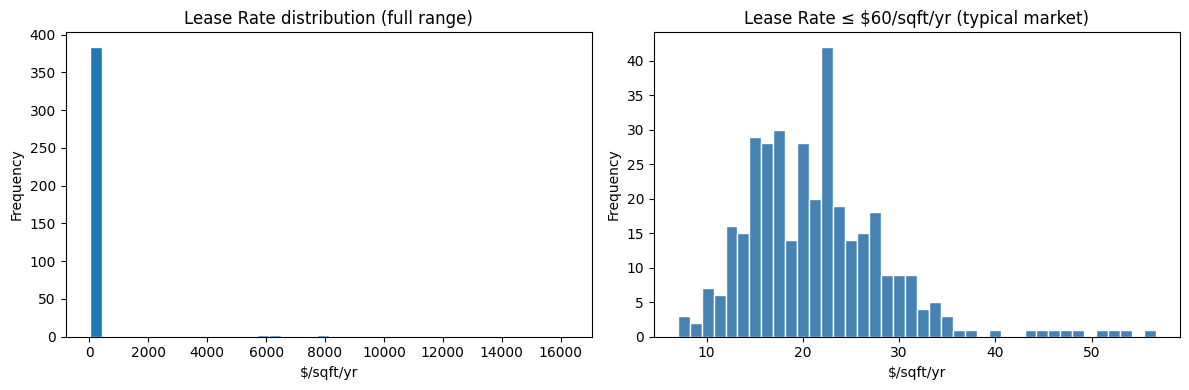


Properties with Lease Rate > $60/sqft/yr: 41 (10.3%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

office[TARGET].plot.hist(bins=40, ax=axes[0], edgecolor="white")
axes[0].set_title("Lease Rate distribution (full range)")
axes[0].set_xlabel("$/sqft/yr")

office[TARGET][office[TARGET] <= 60].plot.hist(bins=40, ax=axes[1], edgecolor="white", color="steelblue")
axes[1].set_title("Lease Rate ≤ $60/sqft/yr (typical market)")
axes[1].set_xlabel("$/sqft/yr")

plt.tight_layout()
plt.show()

print(f"\nProperties with Lease Rate > $60/sqft/yr: {(office[TARGET] > 60).sum()} "
      f"({(office[TARGET] > 60).mean()*100:.1f}%)")

## 6. FRED Macro Integration

Each lease transaction is stamped with a `Date sold`.  We map that date to the
corresponding FRED quarter and left-join all 27 macro indicators so the model
can capture the interest-rate and credit environment at the time of the deal.

In [22]:
# ── 6.1  Parse Date sold & extract quarter label ─────────────────────────
office["date_sold"] = pd.to_datetime(office["Date sold"], errors="coerce")

missing_dates = office["date_sold"].isna().sum()
print(f"Rows with unparseable Date sold: {missing_dates}")
print(f"Date range in data: {office['date_sold'].min().date()} → {office['date_sold'].max().date()}")

# Quarter label: "2022Q2" — matches FRED's 'quarter' column
office["quarter"] = office["date_sold"].dt.to_period("Q").astype(str)
print("\nTransaction quarter distribution (top 10):")
print(office["quarter"].value_counts().sort_index().tail(10))

Rows with unparseable Date sold: 0
Date range in data: 2000-01-06 → 2026-03-03

Transaction quarter distribution (top 10):
quarter
2023Q4     6
2024Q1     9
2024Q2     6
2024Q3     2
2024Q4    10
2025Q1    10
2025Q2    11
2025Q3     9
2025Q4    12
2026Q1     3
Name: count, dtype: int64


In [23]:
# ── 6.2  Prepare FRED panel ───────────────────────────────────────────────
fred = fred_raw.copy()
fred["quarter_end"] = pd.to_datetime(fred["quarter_end"])

# Columns to use from FRED (drop redundant / duplicate label columns)
fred_drop = ["quarter_end", "Chicago Fed NFCI", "Fed Funds Rate (%)"]
fred_keep = [c for c in fred.columns if c not in fred_drop]
fred = fred[fred_keep]

print(f"FRED columns kept ({len(fred_keep)}):")
print(fred_keep)
print(f"\nFRED quarter range: {fred['quarter'].min()} → {fred['quarter'].max()}")
print(f"Office quarter range: {office['quarter'].min()} → {office['quarter'].max()}")

FRED columns kept (26):
['quarter', 'GDPC1', 'UNRATE', 'PAYEMS', 'M2V', 'SUBLPDRCSC', 'CREACBW027SBOG', 'MDOAH', 'M2SL', 'FEDFUNDS', 'NFCI', 'DFII10', 'T10Y2Y', 'WPUSI012011', 'DGS10', 'DGS2', 'MORTGAGE30US', 'CPIAUCSL', 'BAMLC0A4CBBB', 'DTWEXBGS', 'Mortgage Debt / GDP', 'Unemployment Rate Squared', 'CPI Inflation QoQ Ann (%)', 'GDP Growth QoQ Ann (%)', 'US Employment Growth QoQ (%)', 'Bank CRE Loan Growth QoQ (%)']

FRED quarter range: 2000Q1 → 2026Q1
Office quarter range: 2000Q1 → 2026Q1


In [24]:
# ── 6.3  Merge FRED onto office dataframe ─────────────────────────────────
n_before = len(office)
office = office.merge(fred, on="quarter", how="left")
print(f"Rows before merge: {n_before}  →  after: {len(office)}")

# Check coverage (rows that didn't match any FRED quarter)
unmatched = office[office["GDPC1"].isna()]["quarter"].unique()
print(f"Quarters with no FRED match: {unmatched}")

# Fill any residual NAs in FRED columns with column median
fred_cols = [c for c in fred.columns if c != "quarter"]
fred_na = office[fred_cols].isnull().sum()
fred_na = fred_na[fred_na > 0]
if len(fred_na):
    print("\nFRED columns with NAs (filled with median):")
    for col, n in fred_na.items():
        med = office[col].median()
        office[col] = office[col].fillna(med)
        print(f"  {col:35s}  {n} NAs  →  median = {med:.4g}")
else:
    print("\nNo residual NAs in FRED columns.")

print(f"\nShape after FRED merge: {office.shape}")

Rows before merge: 398  →  after: 398
Quarters with no FRED match: ['2026Q1']

FRED columns with NAs (filled with median):
  GDPC1                                3 NAs  →  median = 2.079e+04
  M2V                                  3 NAs  →  median = 1.41
  SUBLPDRCSC                           61 NAs  →  median = 11.1
  CREACBW027SBOG                       10 NAs  →  median = 2399
  MDOAH                                219 NAs  →  median = 1.433e+07
  DFII10                               8 NAs  →  median = 0.4989
  DTWEXBGS                             17 NAs  →  median = 115
  Mortgage Debt / GDP                  219 NAs  →  median = 748
  CPI Inflation QoQ Ann (%)            2 NAs  →  median = 2.855
  GDP Growth QoQ Ann (%)               2 NAs  →  median = 2.61
  US Employment Growth QoQ (%)         2 NAs  →  median = 0.3883
  Bank CRE Loan Growth QoQ (%)         10 NAs  →  median = 1.532

Shape after FRED merge: (398, 57)


## 7. GreenStreet Submarket Integration

GreenStreet publishes quality grades and demographic scores for 13 Dallas/Fort Worth
office submarkets.  We map each Crexi property to a submarket using city name (with
zip-code refinement for properties in the city of Dallas) and join the 12 submarket
metrics as additional features.

In [25]:
# ── 7.1  Load GreenStreet Office Submarket Grades ─────────────────────────
gs_raw = pd.read_excel(GS_FILE, sheet_name="Office Submarket Grades", header=None)

# Row 2 contains the actual column headers
gs_cols = gs_raw.iloc[2].tolist()
gs = gs_raw.iloc[3:].copy()
gs.columns = gs_cols
gs = gs.reset_index(drop=True)

# Keep Dallas / Fort Worth only
gs_dfw = gs[gs["Market"] == "Dallas / Fort Worth"].copy()
gs_dfw = gs_dfw.reset_index(drop=True)

# Rename for clarity
gs_dfw = gs_dfw.rename(columns={"Submarket": "gs_submarket"})

# Convert numeric columns
gs_numeric = ["Submarket Grade Rank", "Desirability Index", "Median Household Income",
              "% College Degree", "% Office Establishments", "Population Density",
              "Distance to CBD"]
for col in gs_numeric:
    gs_dfw[col] = pd.to_numeric(gs_dfw[col], errors="coerce")

print("Dallas/Fort Worth submarkets:")
print(gs_dfw[["gs_submarket", "Submarket Grade", "Submarket Grade Rank", "Desirability Index"]].to_string(index=False))

Dallas/Fort Worth submarkets:
                 gs_submarket Submarket Grade  Submarket Grade Rank  Desirability Index
                 Dallas (CBD)               A                    98               60.91
                    Far North              A-                   164               59.83
               Fort Worth CBD              B+                   238               48.91
                  Las Colinas               A                   117               69.24
                   Mid-Cities              A-                   165               66.53
             North Fort Worth              B+                   213               65.75
         Northeast Fort Worth               B                   389               47.57
               Preston Center             A++                    15               70.95
Richardson / Plano / McKinney               A                   109               74.89
             South Fort Worth              B+                   258               55.86
  

In [26]:
# ── 7.2  City → GreenStreet submarket mapping ─────────────────────────────
#
# Dallas zips: CBD ≈ 75201-75215 | Uptown ≈ 75219 | Preston Center ≈ 75225/30/40/43/48/52
#              Stemmons ≈ 75207/75247 | Far North ≈ 75234/75244

DALLAS_ZIP_SUBMARKET = {
    "75201": "Dallas (CBD)", "75202": "Dallas (CBD)", "75203": "Dallas (CBD)",
    "75204": "Dallas (CBD)", "75205": "Dallas (CBD)", "75206": "Dallas (CBD)",
    "75207": "Stemmons Freeway", "75208": "Dallas (CBD)", "75210": "Dallas (CBD)",
    "75211": "Southwest", "75212": "Dallas (CBD)", "75215": "Dallas (CBD)",
    "75216": "Southwest", "75217": "Southwest",
    "75219": "Uptown / Turtle Creek",
    "75220": "Stemmons Freeway", "75229": "Stemmons Freeway", "75247": "Stemmons Freeway",
    "75225": "Preston Center", "75230": "Preston Center", "75240": "Preston Center",
    "75243": "Preston Center", "75244": "Preston Center", "75248": "Preston Center",
    "75252": "Preston Center",
    "75231": "Far North", "75234": "Far North",
}

CITY_SUBMARKET = {
    # Las Colinas / Irving
    "IRVING": "Las Colinas", "GRAND PRAIRIE": "Las Colinas", "COPPELL": "Las Colinas",
    # Richardson / Plano / McKinney
    "PLANO": "Richardson / Plano / McKinney", "MCKINNEY": "Richardson / Plano / McKinney",
    "RICHARDSON": "Richardson / Plano / McKinney", "ALLEN": "Richardson / Plano / McKinney",
    "FRISCO": "Richardson / Plano / McKinney", "GARLAND": "Richardson / Plano / McKinney",
    "ROWLETT": "Richardson / Plano / McKinney", "ROCKWALL": "Richardson / Plano / McKinney",
    "MESQUITE": "Richardson / Plano / McKinney", "HEATH": "Richardson / Plano / McKinney",
    "ANNA": "Richardson / Plano / McKinney", "CELINA": "Richardson / Plano / McKinney",
    "GREENVILLE": "Richardson / Plano / McKinney",
    # Far North Dallas
    "PROSPER": "Far North", "ADDISON": "Far North",
    # Stemmons Freeway corridor
    "FARMERS BRANCH": "Stemmons Freeway", "CARROLLTON": "Stemmons Freeway",
    # Mid-Cities (between Dallas & Fort Worth)
    "ARLINGTON": "Mid-Cities", "EULESS": "Mid-Cities", "BEDFORD": "Mid-Cities",
    "HURST": "Mid-Cities", "GRAPEVINE": "Mid-Cities", "SOUTHLAKE": "Mid-Cities",
    "COLLEYVILLE": "Mid-Cities", "FLOWER MOUND": "Mid-Cities", "LEWISVILLE": "Mid-Cities",
    "HIGHLAND VILLAGE": "Mid-Cities", "DENTON": "Mid-Cities",
    # Fort Worth
    "FORT WORTH": "Fort Worth CBD", "DALWORTHINGTON GARDENS": "Fort Worth CBD",
    "WEATHERFORD": "Fort Worth CBD", "DECATUR": "Fort Worth CBD",
    # North Fort Worth
    "NORTH RICHLAND HILLS": "North Fort Worth", "KELLER": "North Fort Worth",
    "WATAUGA": "North Fort Worth", "HALTOM CITY": "North Fort Worth",
    # Northeast Fort Worth
    # South Fort Worth
    "KENNEDALE": "South Fort Worth", "BURLESON": "South Fort Worth",
    "MANSFIELD": "South Fort Worth", "JOSHUA": "South Fort Worth",
    "CLEBURNE": "South Fort Worth",
    # Southwest Dallas
    "DUNCANVILLE": "Southwest", "CEDAR HILL": "Southwest", "DESOTO": "Southwest",
    "LANCASTER": "Southwest", "MIDLOTHIAN": "Southwest",
}

def assign_submarket(row):
    city = str(row["City"]).strip().upper()
    zip_raw = str(row["Zip code"]).strip()
    zip5 = zip_raw[:5]

    if city == "DALLAS":
        return DALLAS_ZIP_SUBMARKET.get(zip5, "Dallas (CBD)")
    return CITY_SUBMARKET.get(city, "Unknown")

office["gs_submarket"] = office.apply(assign_submarket, axis=1)

print("Submarket assignment distribution:")
print(office["gs_submarket"].value_counts().to_string())
print(f"\nUnmapped properties: {(office['gs_submarket'] == 'Unknown').sum()}")

Submarket assignment distribution:
gs_submarket
Richardson / Plano / McKinney    117
Mid-Cities                        72
Las Colinas                       46
Fort Worth CBD                    33
Stemmons Freeway                  29
Dallas (CBD)                      28
Preston Center                    21
Far North                         15
Southwest                         12
North Fort Worth                  11
South Fort Worth                   7
Uptown / Turtle Creek              7

Unmapped properties: 0


In [27]:
# ── 7.3  Merge GreenStreet metrics ────────────────────────────────────────
gs_features = gs_dfw[["gs_submarket", "Submarket Grade", "Submarket Grade Rank",
                        "Fiscal Health", "Supply Barriers", "Desirability Index",
                        "Business Friendliness", "Climate Event Risk",
                        "Median Household Income", "% College Degree",
                        "% Office Establishments", "Population Density",
                        "Distance to CBD"]].copy()

# Prefix GreenStreet columns to avoid collisions
gs_features = gs_features.rename(columns={
    c: f"gs_{c.lower().replace(' ', '_').replace('%_', 'pct_').replace('/', '_')}"
    for c in gs_features.columns if c != "gs_submarket"
})

n_before = len(office)
office = office.merge(gs_features, on="gs_submarket", how="left")
print(f"Rows before: {n_before}  →  after: {len(office)}")

# Properties with 'Unknown' submarket won't have GreenStreet data → fill with median
gs_cols_new = [c for c in gs_features.columns if c != "gs_submarket"]
gs_num_new  = office[gs_cols_new].select_dtypes(include=[np.number]).columns.tolist()
gs_cat_new  = office[gs_cols_new].select_dtypes(include="object").columns.tolist()

office[gs_num_new] = office[gs_num_new].fillna(office[gs_num_new].median())
office[gs_cat_new] = office[gs_cat_new].fillna("Unknown")

print(f"\nGreenStreet columns added ({len(gs_cols_new)}): {gs_cols_new}")
print(f"\nShape after GreenStreet merge: {office.shape}")
print(f"Total NAs remaining: {office.isnull().sum().sum()}")

Rows before: 398  →  after: 398

GreenStreet columns added (12): ['gs_submarket_grade', 'gs_submarket_grade_rank', 'gs_fiscal_health', 'gs_supply_barriers', 'gs_desirability_index', 'gs_business_friendliness', 'gs_climate_event_risk', 'gs_median_household_income', 'gs_pct_college_degree', 'gs_pct_office_establishments', 'gs_population_density', 'gs_distance_to_cbd']

Shape after GreenStreet merge: (398, 70)
Total NAs remaining: 0


## 8. Final Dataset

Summary of the fully preprocessed dataset, ready for Layer 1 hedonic modelling.

In [28]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"  Observations : {office.shape[0]}")
print(f"  Features     : {office.shape[1] - 1}  (excl. target)")
print(f"  Target       : '{TARGET}'")
print(f"  Total NAs    : {office.isnull().sum().sum()}")
print()

# Feature breakdown
all_num  = office.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
all_cat  = office.select_dtypes(include="object").columns.tolist()
fred_f   = [c for c in all_num if c in fred.columns or c == "Unemployment Rate Squared"]
gs_f     = [c for c in office.columns if c.startswith("gs_")]
crexi_f  = [c for c in office.columns if c not in fred_f + gs_f + [TARGET, "quarter", "date_sold"]]

print(f"  Crexi features    : {len(crexi_f)}")
print(f"  FRED macro        : {len(fred_f)}")
print(f"  GreenStreet       : {len(gs_f)}")
print(f"  Date helpers      : quarter, date_sold")
print()
print(f"  Lease Rate stats:")
print(office[TARGET].describe().to_string())
print()
print("Columns overview:")
print(office.dtypes.to_string())

FINAL DATASET SUMMARY
  Observations : 398
  Features     : 69  (excl. target)
  Target       : 'Lease rate'
  Total NAs    : 0

  Crexi features    : 29
  FRED macro        : 25
  GreenStreet       : 13
  Date helpers      : quarter, date_sold

  Lease Rate stats:
count     398.00
mean      285.68
std      1545.69
min         6.98
25%        16.50
50%        21.96
75%        27.94
max     16250.00

Columns overview:
Record type                             object
Property type                           object
Property subtype                        object
Interest rate                          float64
Date sold                               object
Sold price                              object
Sold price/sqft                         object
Property name                           object
Total monthly rate                     float64
Loan amount                            float64
Loan type                               object
Lease rate                             float64
Financing matur

In [29]:
office.to_csv(DATA_DIR + "office_preprocessed.csv", index=False)
print("Saved → office_preprocessed.csv")
office.head(3)

Saved → office_preprocessed.csv


,Record type,Property type,Property subtype,Interest rate,Date sold,Sold price,Sold price/sqft,Property name,Total monthly rate,Loan amount,Loan type,Lease rate,Financing maturity date,Title company,Building sqft,Number of units,Year built,Lot size acres,Sold price/acre,Lot size sqft,Lease type,Rent bumps,Tenancy,Address,City,Zip code,State,County,Building count,Transaction Type,date_sold,quarter,GDPC1,UNRATE,PAYEMS,M2V,SUBLPDRCSC,CREACBW027SBOG,MDOAH,M2SL,FEDFUNDS,NFCI,DFII10,T10Y2Y,WPUSI012011,DGS10,DGS2,MORTGAGE30US,CPIAUCSL,BAMLC0A4CBBB,DTWEXBGS,Mortgage Debt / GDP,Unemployment Rate Squared,CPI Inflation QoQ Ann (%),GDP Growth QoQ Ann (%),US Employment Growth QoQ (%),Bank CRE Loan Growth QoQ (%),gs_submarket,gs_submarket_grade,gs_submarket_grade_rank,gs_fiscal_health,gs_supply_barriers,gs_desirability_index,gs_business_friendliness,gs_climate_event_risk,gs_median_household_income,gs_pct_college_degree,gs_pct_office_establishments,gs_population_density,gs_distance_to_cbd
0,Sale Comp Lease Data,Office,Traditional Office,6.06,"Mar 3, 2026","$693,007",$108,"17768 Preston Road, Dallas, Texas 75252",5947.57,521058.00,New Conventional,13.00,"Jul 14, 2028",LAWYERS TITLE,"6,446",1.00,1985.00,0.10,"$6,650,739","333,822",NNN,No,Multi,17768 PRESTON RD,DALLAS,75252,TX,COLLIN,2.00,Arms-length Residential transactions (Purchase...,2026-03-03,2026Q1,20791.92,4.35,158466,1.41,1.80,3074.26,14332418.23,22667.30,3.64,-0.53,1.86,0.63,349.95,4.18,3.55,6.08,327.46,1.01,118.88,748.05,18.92,1.75,0.00,0.02,0.40,Preston Center,A++,15,Healthy,Average,70.95,Very Friendly,Average,110,0.60,0.40,5440,8.47
1,Sale Comp Lease Data,Office,Traditional Office,6.16,"Feb 18, 2026","$6,084,750",$64,524 Lamar,9963.65,4575000.00,New Conventional,17.00,"Feb 17, 2036",TITLE PARTNERS,"95,355",150.00,1981.00,4.55,"$1,336,838","195,497",Unknown,No,Multi,524 E LAMAR BLVD,ARLINGTON,76011-3929,TX,TARRANT,1.00,Arms-length Residential transactions (Purchase...,2026-02-18,2026Q1,20791.92,4.35,158466,1.41,1.80,3074.26,14332418.23,22667.30,3.64,-0.53,1.86,0.63,349.95,4.18,3.55,6.08,327.46,1.01,118.88,748.05,18.92,1.75,0.00,0.02,0.40,Mid-Cities,A-,165,Healthy,Very Low,66.53,Very Friendly,Average,97,0.36,0.22,3610,13.88
2,Sale Comp Lease Data,Office,Shopping Center,6.16,"Feb 18, 2026","$771,400",$279,201 N Broadway St,3714.45,580000.00,Seller take-back,14.00,Unknown,PROVIDENCE TITLE COMPANY,"2,762",1.00,2001.00,0.77,"$1,001,948","34,848",NNN,No,Single,201 N BROADWAY ST,JOSHUA,76058,TX,JOHNSON,2.00,Arms-length Residential transactions (Purchase...,2026-02-18,2026Q1,20791.92,4.35,158466,1.41,1.80,3074.26,14332418.23,22667.30,3.64,-0.53,1.86,0.63,349.95,4.18,3.55,6.08,327.46,1.01,118.88,748.05,18.92,1.75,0.00,0.02,0.40,South Fort Worth,B+,258,Healthy,Very Low,55.86,Very Friendly,High,87,0.34,0.20,2920,10.05
